In [113]:
import numpy as np
import matplotlib.pyplot as plt
import construct as ut
import os
import pickle
import PcmPy as pcm
import seaborn as sns
import pandas as pd
import OptimalBattery.evaluate as ev
import Functional_Fusion.atlas_map as am
from Functional_Fusion.dataset import DataSetMDTB
from IndividualParcellation.global_config import *
import OptimalBattery.estimate as es
import OptimalBattery.util as ut
import OptimalBattery.construct as ct
import OptimalBattery.plot as plot

# define atlas and dirs

In [114]:
space = 'SUIT3'
atlas,_= am.get_atlas(atlas_str=space)
base_dir = 'Y:/data/'
if not os.path.exists(base_dir):
    base_dir = '/cifs/diedrichsen/data/'

func_fus_dir = os.path.join(base_dir, 'FunctionalFusion')
cerebellum_dir = os.path.join(base_dir, 'Cerebellum')

In [115]:
region_mapping = {
    (1, 2, 3, 4): 1,
    (5, 6, 7): 2,
    (8, 9, 10, 11): 3,
    (12, 13, 14, 15, 16): 4,
    (17, 18, 19, 20): 5,  
    (21, 22, 23): 6,
    (24, 25, 26, 27): 7,
    (28, 29, 30, 31, 32): 8
}

In [116]:
# roi (full cerebellum)
atlas_dir = f'{func_fus_dir}/Atlases/tpl-SUIT'
model_name = f'{atlas_dir}/atl-NettekovenSym32_space-SUIT_dseg.nii'
parcelation = atlas.read_data(model_name)

flat_mapping = {k: v for keys, v in region_mapping.items() for k in keys}

# Vectorized mapping function
parcelation = np.vectorize(lambda x: flat_mapping.get(int(x), x))(parcelation)


ROI_to_include = [3,4,7,8]
# make a mask of the cerebellum
ROI_mask = np.isin(parcelation, ROI_to_include).astype(int)

# get the indices of the voxels in the mask
ROI_indices = np.where(ROI_mask)[0]
len(ROI_indices)

3988

# Load data

- mdtb_1 - run: Data used to make G libray of tasks and to construct artificial batteries for parcellation
- mdtb_1 - all: Data used to estimate Vs within parcels in initial parcellation
- mdtb_2 - all: Data used to test parcellation predicition error

In [117]:
MDTB_dataset = DataSetMDTB(f'{func_fus_dir}/MDTB')

data_mdtb_s1_run,info_mdtb_1_run  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='CondRun')
data_mdtb_s1_run[np.isnan(data_mdtb_s1_run)] = 0
data_mdtb_s1_run = data_mdtb_s1_run[:,:,:]



data_mdtb_s1_all,info_mdtb_1_all  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='CondAll')
data_mdtb_s1_all[np.isnan(data_mdtb_s1_all)] = 0
data_mdtb_s1_all = data_mdtb_s1_all[:,:,:]


data_mdtb_s2_all,info_mdtb_2_all  =MDTB_dataset.get_data(space=space,ses_id='ses-s2',type='CondAll')
data_mdtb_s2_all[np.isnan(data_mdtb_s2_all)] = 0


recenter data around rest so that the variance in the Glibrary is signal compared to rest  
centers each row around the rest in its run and make rest a row of zeros


In [118]:
data_mdtb_s1_run = ut.recenter_fmri_data(data_mdtb_s1_run,info_mdtb_1_run,task_column_name='cond_name',center_condition='rest')
data_mdtb_s1_all = ut.recenter_fmri_data(data_mdtb_s1_all,info_mdtb_1_all,task_column_name='cond_name',center_condition='rest')

# Get crossvalidated second moment matrix across subjects (GLib)

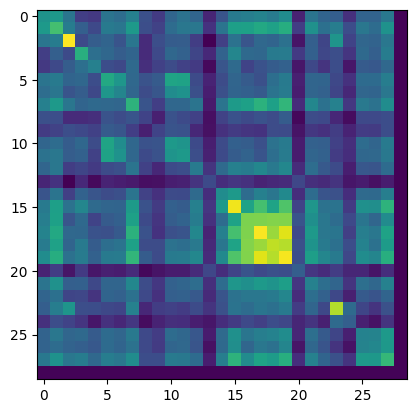

In [87]:
cond_vec = np.tile(np.arange(1, 29 + 1), 16)
part_vec = np.repeat(np.arange(1, 16 + 1), 29)
Gs_list = []
E_list = []
for i in range(data_mdtb_s1_run.shape[0]):
    Gs,E = pcm.util.est_G_crossval(data_mdtb_s1_run[i][:,ROI_indices] , cond_vec, part_vec)
    Gs_list.append(Gs)
    E_list.append(E)

Gs_list = np.stack(Gs_list, 0)
G_Lib = np.mean(Gs_list, axis=0)

plt.imshow(G_Lib, cmap='viridis')

# Build dataframes with different task battery size (n_tasks) and different number of parcels (n_parcels) and evaluate

In [119]:
# make variables torch
device = pt.device('cuda' if pt.cuda.is_available() else 'cpu')
data_mdtb_s1_all = pt.tensor(data_mdtb_s1_all, dtype=pt.float32, device=device)
data_test = pt.tensor(data_mdtb_s2_all, dtype=pt.float32, device=device)
data_train = pt.tensor(data_mdtb_s1_run, dtype=pt.float32, device=device)
parcelation = pt.tensor(parcelation, dtype=pt.float32, device=device)
ROI_mask = pt.tensor(ROI_mask, dtype=pt.float32, device=device)


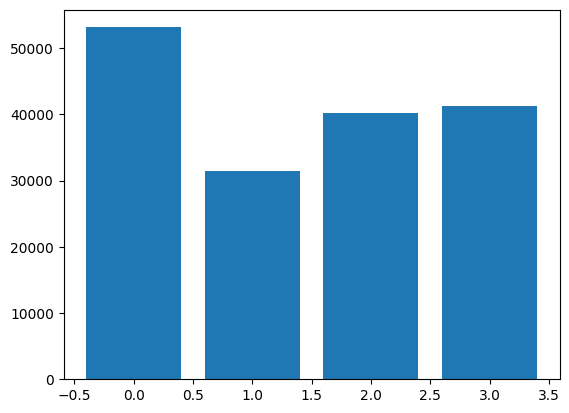

In [89]:
# estimate Vs for session 1 using s1 full data
full_vs_train = es.estimate_Vs(data_mdtb_s1_all,parcellation=parcelation,ROI_mask= ROI_mask)
full_vs_train = ut.center_matrix(full_vs_train,axis=0)
full_vs_train = ut.normalize_matrix(full_vs_train,axis=0)

# estimate Vs for session 2 using s2 full data
full_vs_test = es.estimate_Vs(data_test,parcellation=parcelation,ROI_mask=ROI_mask)
full_vs_test = ut.center_matrix(full_vs_test,axis=0)
full_vs_test = ut.normalize_matrix(full_vs_test,axis=0)

# Get list of parcels ordered by size by counting voxel assignments across subjects (using Vs from session 1)
Us = es.estimate_Us(data_mdtb_s1_all, full_vs_train,method='correlation',hard=True)
parcel_counts = Us.sum(dim=(0,2))
sorted_parcels = pt.argsort(parcel_counts, descending=True).cpu().numpy()
parcel_counts = parcel_counts.cpu().numpy()
total_parcels = len(sorted_parcels)

plt.bar(range(len(parcel_counts)), parcel_counts)
plt.show()

In [90]:
# get dataframe that contains length of each regressor from mdtb-s1 and the indices of the regressor
condition_df= ct.get_condition_indices(info_mdtb_1_run)

In [96]:
# define ranges of battery and parcel sizes
battery_sizes = [3,4,5,6,7,8,10,14,16]
# parcel_sizes = [2,4,6,8,10,16,total_parcels]

parcel_sizes = [2,3,4]
# battery_sizes = [4,6]


In [97]:
results_df = pd.DataFrame()
for n_parcel in parcel_sizes:
    print(f"Processing parcel size: {n_parcel}")
    # only pick the top n parcels 
    parcel_indices = sorted_parcels[:n_parcel]
    VLib = full_vs_train[:,parcel_indices]
    Vtest = full_vs_test[:,parcel_indices]
    for n_task in battery_sizes:
        print(f"Processing battery size: {n_task}")
        # Generate possible battery combinations for current battery size and calculate eigenmetrics
        D = ct.build_combinations(G_Lib, strategy='random',n_batteries=1000,n_tasks=n_task,seed=1,replacement=False,rest_idx=28)
        # Make a artificial battery data + parcellation for each battery for each subject and evaluate on session 2
        D_ev = ev.evluate_dataframe( D = D, condition_df= condition_df, YLib= data_train,
                                     VLib= VLib, Ytest= data_test, Vtest= Vtest,indices=ROI_indices,method='correlation',hard=True)

        D_ev['n_parcel'] = n_parcel
        D_ev['n_task'] = n_task

        results_df = pd.concat([results_df, D_ev], ignore_index=True)
    



Processing parcel size: 2
Processing battery size: 3
Processing combination: 0
Processing battery size: 4
Processing combination: 0
Processing battery size: 5
Processing combination: 0
Processing battery size: 6
Processing combination: 0
Processing battery size: 7
Processing combination: 0
Processing battery size: 8
Processing combination: 0
Processing battery size: 10
Processing combination: 0
Processing battery size: 14
Processing combination: 0
Processing battery size: 16
Processing combination: 0
Processing parcel size: 3
Processing battery size: 3
Processing combination: 0
Processing battery size: 4
Processing combination: 0
Processing battery size: 5
Processing combination: 0
Processing battery size: 6
Processing combination: 0
Processing battery size: 7
Processing combination: 0
Processing battery size: 8
Processing combination: 0
Processing battery size: 10
Processing combination: 0
Processing battery size: 14
Processing combination: 0
Processing battery size: 16
Processing com

In [ ]:
name = os.path.join(base_dir, 'OptimalBattery','Eval_tsvs', 'cerebellum_SD_MDTB_ses-01_ses-02_results_correlation.tsv')

# save to tsv
# results_df.to_csv(name, sep="\t", index=False)

#load
# results_df = pd.read_csv(name, sep="\t")

# Make proposal sets (sampling with repelcament from the batteries evaluated) for each n_tasks and n_parcels

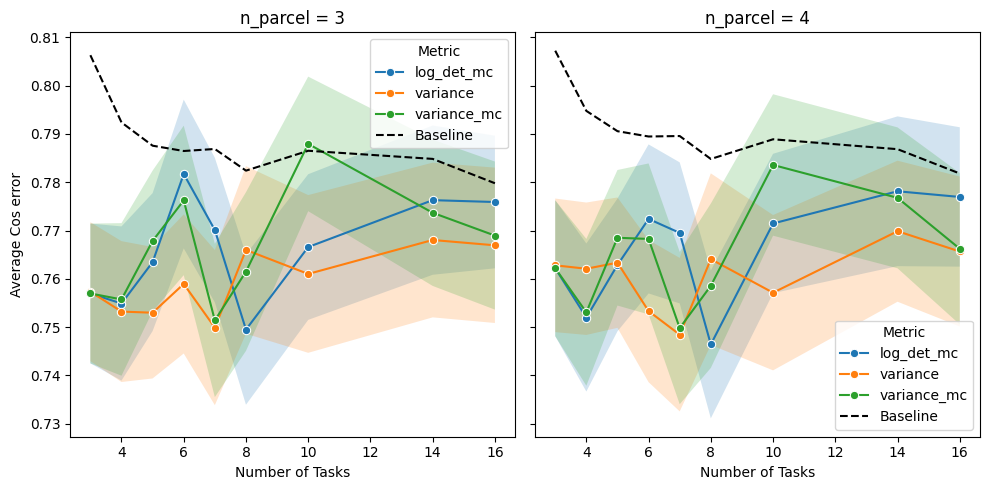

In [94]:
metrics = ["variance", "variance_mc", "log_det_mc"]
n_proposal_sets = 100
resampled_results_df = plot.resample_df(results_df, metrics, n_proposal_sets)
expanded_results_df = plot.expand_subject_results(resampled_results_df)
aggregated_results_df = plot.compute_aggregated_results(expanded_results_df)
baseline_aggregated_df = plot.compute_baseline(results_df)
plot.plot_results(aggregated_results_df, baseline_aggregated_df)

In [ ]:
def find_single_contrast(Vs,):

In [183]:
space = 'SUIT3'
atlas,_= am.get_atlas(atlas_str=space)
base_dir = 'Y:/data/'
if not os.path.exists(base_dir):
    base_dir = '/cifs/diedrichsen/data/'

func_fus_dir = os.path.join(base_dir, 'FunctionalFusion')
cerebellum_dir = os.path.join(base_dir, 'Cerebellum')
region_mapping = {
    (1, 2, 3, 4): 1,
    (5, 6, 7): 2,
    (8, 9, 10, 11): 3,
    (12, 13, 14, 15, 16): 4,
    (17, 18, 19, 20): 5,  
    (21, 22, 23): 6,
    (24, 25, 26, 27): 7,
    (28, 29, 30, 31, 32): 8
}
# roi (full cerebellum)
atlas_dir = f'{func_fus_dir}/Atlases/tpl-SUIT'
model_name = f'{atlas_dir}/atl-NettekovenSym32_space-SUIT_dseg.nii'
parcelation_32 = atlas.read_data(model_name)

flat_mapping = {k: v for keys, v in region_mapping.items() for k in keys}

# Vectorized mapping function
parcelation_8 = np.vectorize(lambda x: flat_mapping.get(int(x), x))(parcelation_32)


ROI_to_include = [1,2,3,4,5,6,7,8]
# ROI_to_include = np.arange(1,33)
# make a mask of the cerebellum
ROI_mask = np.isin(parcelation_8, ROI_to_include).astype(int)



In [184]:
# make variables torch
parcelation = pt.tensor(parcelation_8, dtype=pt.float32, device=device)
ROI_mask = pt.tensor(ROI_mask, dtype=pt.float32, device=device)


In [185]:
# estimate Vs for session 1 using s1 full data
full_vs_train = es.estimate_Vs(data_mdtb_s1_all,parcellation=parcelation,ROI_mask= ROI_mask)
full_vs_train = ut.center_matrix(full_vs_train,axis=0)
full_vs_train = ut.normalize_matrix(full_vs_train,axis=0)

In [186]:
task_names  = info_mdtb_1_all['cond_name'].unique()

In [189]:
full_vs_train.shape

torch.Size([29, 8])

In [187]:
SR = full_vs_train[:,7].cpu().numpy()
DR = full_vs_train[:,6].cpu().numpy()


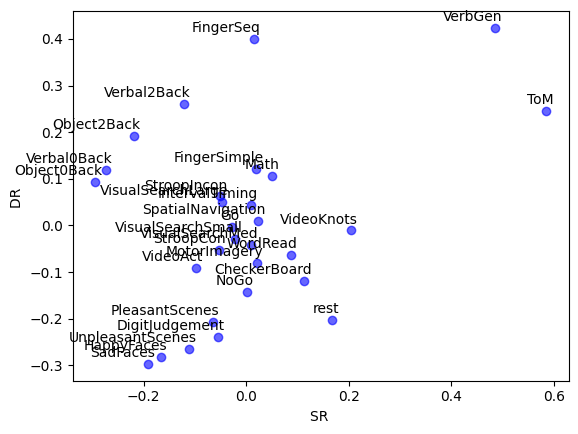

In [ ]:
plt.scatter(SR, DR, color='b', alpha=0.6)
for i, task in enumerate(task_names):
    plt.annotate(task, (SR[i], DR[i]), textcoords="offset points", xytext=(5,5), ha='right')

# Labels and title
plt.xlabel("SR ")
plt.ylabel("DR ")

plt.show()


In [ ]:
difference = SR - DR

array([ 1.43293411e-01, -2.32320223e-02,  3.40230107e-01, -7.44382292e-03,
        2.14561597e-01,  1.53771535e-01,  1.40854955e-01, -5.54457940e-02,
        1.84522480e-01,  2.33172446e-01,  1.05181485e-01,  1.16432592e-01,
       -3.46639790e-02,  1.01874858e-01, -1.01773001e-01, -3.85422826e-01,
       -3.93502533e-01, -3.82973135e-01, -3.86281252e-01, -4.10073698e-01,
        1.36182457e-02, -1.12426445e-01,  1.35540962e-04,  6.21314347e-02,
        1.50370896e-01,  8.22961703e-03,  5.12151197e-02, -9.82578397e-02,
        3.71900082e-01], dtype=float32)